# 🌪️ X/Twitter strategy audit: filtered volatility risk premium

## 🧭 tl;dr

Concretum Research described volatility-based approaches using the volatility risk premium, implied-versus-realized volatility, VIX term structure, and dynamic sizing. This notebook implements a conservative educational proxy: short a VXX-like long-volatility instrument only when the VIX premium and term structure are supportive, with exposure scaled by the premium and capped at one.

> Educational research only. Not financial advice. Short-volatility strategies can lose money quickly; this notebook is a research artifact, not a trade recommendation.

<div style="border-left: 5px solid #DC2626; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #FEF2F2; border-radius: 8px;"><strong>⚠️ Safety note</strong><br>VXX is a product proxy, not a VIX future or options portfolio. The strategy is intentionally labeled an approximation and includes explicit crisis windows.</div>


## 📚 Source and research question

The X post says Concretum’s volatility research starts with passive short volatility, then adds filters based on implied versus realized volatility, VIX term structure, and dynamic sizing. It also explicitly warns about volatility-product complexity and the 2018 Volmageddon event.

Source: [Concretum Research X post](https://x.com/ConcretumR/status/1952298941745172695).

**Research question:** do simple volatility filters improve a short-VXX proxy’s risk-adjusted behavior versus unfiltered short VXX, and how much damage remains in stress windows?


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_data, load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_volatility_data():
    try:
        vxx = load_price_data("VXX", "2009-01-01", "2026-01-01")["close"].rename("VXX")
        spy = load_price_data("SPY", "2009-01-01", "2026-01-01")["close"].rename("SPY")
        vix = load_price_data("^VIX", "2009-01-01", "2026-01-01")["close"].rename("VIX")
        try:
            vix3m = load_price_data("^VIX3M", "2009-01-01", "2026-01-01")["close"].rename("VIX3M")
            term_source = "Yahoo Finance ^VIX3M"
        except Exception:
            vix3m = (vix * 1.04).rename("VIX3M")
            term_source = "synthetic 4% VIX3M markup fallback"
        data = pd.concat([vxx, spy, vix, vix3m], axis=1).dropna()
        return data, f"Yahoo Finance VXX, SPY, ^VIX, and {term_source}"
    except Exception as exc:
        demo = make_demo_ohlcv(periods=4_200, seed=707, start="2009-01-01")["close"]
        spy = demo.rename("SPY")
        realized = spy.pct_change().rolling(21).std() * np.sqrt(252) * 100
        vix = (realized + 5.0).clip(lower=10.0).rename("VIX")
        vix3m = (vix * 1.04).rename("VIX3M")
        vxx = (100.0 * np.exp(np.cumsum((vix.diff().fillna(0.0) / 100.0) * 0.02))).rename("VXX")
        return pd.concat([vxx, spy, vix, vix3m], axis=1).dropna(), f"deterministic demo volatility fallback ({type(exc).__name__})"


data, data_source = load_volatility_data()
print(f"Data source: {data_source}")
print(f"Observations: {len(data):,} | {data.index.min().date()} to {data.index.max().date()}")
display(data.head())


Data source: Yahoo Finance VXX, SPY, ^VIX, and Yahoo Finance ^VIX3M
Observations: 1,995 | 2018-01-25 to 2025-12-31


/var/folders/5h/g_xnfdx11sx1rg5979ls_ckm0000gn/T/ipykernel_65372/3787407996.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  data = pd.concat([vxx, spy, vix, vix3m], axis=1).dropna()


,VXX,SPY,VIX,VIX3M
Date,,,,
2018-01-25,1770.239990,248.710190,11.58,13.68
2018-01-26,1770.239990,251.589798,11.08,13.46
2018-01-29,1893.119995,249.921707,13.84,14.99
2018-01-30,1955.199951,247.358246,14.79,15.83
2018-01-31,1961.599976,247.481171,13.54,14.90


## 📜 Filtered short-volatility proxy rules

At each close, use:

- 21-day annualized realized SPY volatility.
- The implied-volatility premium: `VIX − realized volatility`.
- The VIX term-structure slope: `VIX3M − VIX`; positive values approximate contango.
- A 20-day VIX moving average as a simple fear-regime check.

Hold a short VXX position only when:

`VIX > realized volatility`, `VIX3M > VIX`, and `VIX < 1.25 × its 20-day average`.

Size the short position as `min(1, max(0, (VIX − realized) / 10))`. The position is capped at one, is delayed one bar, and pays 10 bps on exposure changes. This is not an options-implied-volatility replication; it is a transparent proxy for the source post’s idea.


In [3]:

def filtered_short_vol_target(data):
    vix = data["VIX"]
    realized = data["SPY"].pct_change().rolling(21).std() * np.sqrt(252) * 100
    term = data["VIX3M"] - vix
    vix_average = vix.rolling(20, min_periods=20).mean()
    premium = vix - realized
    favorable = (premium > 0.0) & (term > 0.0) & (vix < 1.25 * vix_average)
    scale = (premium / 10.0).clip(lower=0.0, upper=1.0)
    target = (-scale.where(favorable, 0.0)).rename("target_position")
    diagnostics = pd.DataFrame({"VIX": vix, "realized_vol": realized, "premium": premium, "term_structure": term, "target_position": target})
    return target.fillna(0.0), diagnostics


target, diagnostics = filtered_short_vol_target(data)
filtered = run_backtest(data["VXX"], target, transaction_cost_bps=10.0, benchmark_returns=data["SPY"].pct_change().fillna(0.0))
unfiltered = run_backtest(data["VXX"], pd.Series(-1.0, index=data.index), transaction_cost_bps=10.0, benchmark_returns=data["SPY"].pct_change().fillna(0.0))
spy_hold = run_backtest(data["SPY"], pd.Series(1.0, index=data.index), transaction_cost_bps=10.0)
splits = split_time_series(data)
periods = {name: frame.index for name, frame in splits.items()}


## 📈 Results: filtered versus unfiltered short volatility

The unfiltered short-VXX line is intentionally included as a warning benchmark. A strategy that looks attractive in calm periods can be exposed to discontinuous losses when volatility spikes.


In [4]:

rows = []
for name, backtest in [("Filtered short-VXX proxy", filtered), ("Unfiltered short VXX", unfiltered), ("SPY buy & hold", spy_hold)]:
    for period_name, period_index in periods.items():
        metrics = metrics_for_period(backtest, period_index)
        rows.append({"strategy": name, "period": period_name, **metrics})
summary = pd.DataFrame(rows).set_index(["strategy", "period"])
display(summary[["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "win_rate", "annualized_turnover", "number_of_trades", "total_return_after_costs"]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "win_rate": "{:.2%}", "annualized_turnover": "{:.2f}", "number_of_trades": "{:.0f}", "total_return_after_costs": "{:.2%}"}))


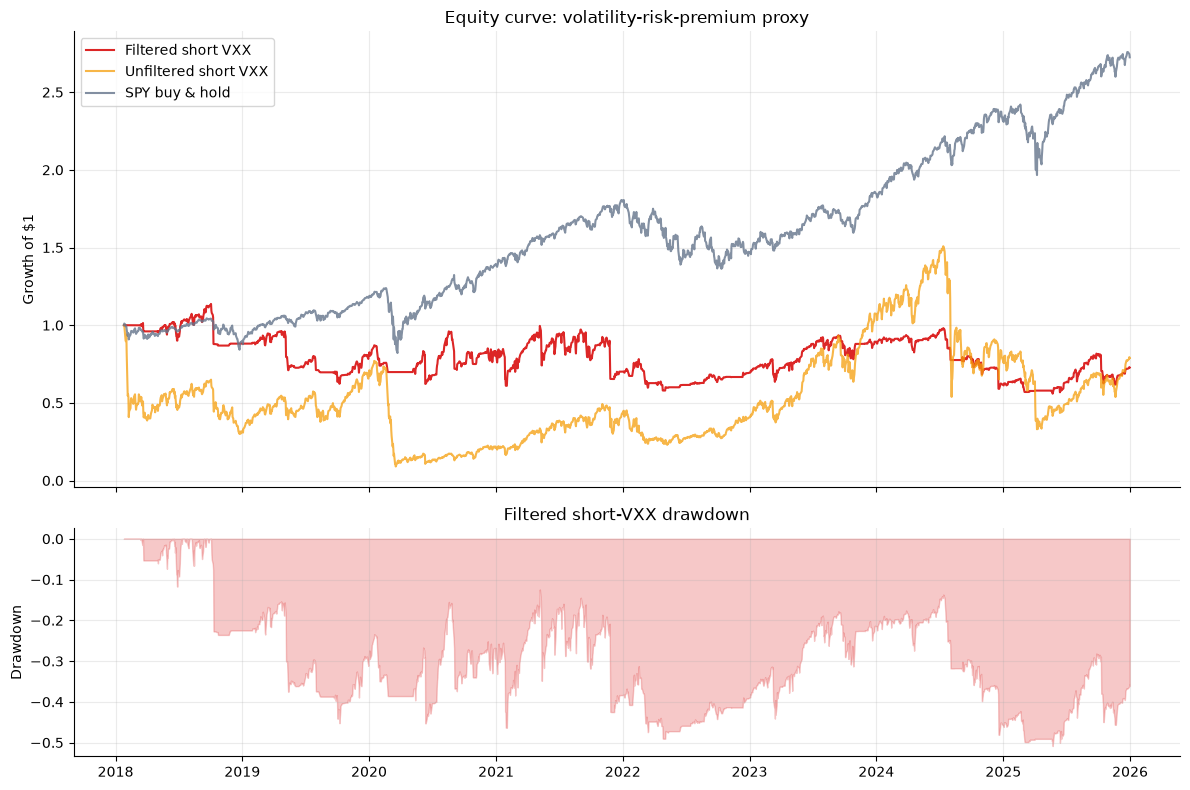

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(filtered.frame.index, filtered.equity / filtered.equity.iloc[0], label="Filtered short VXX", color="#DC2626")
axes[0].plot(unfiltered.frame.index, unfiltered.equity / unfiltered.equity.iloc[0], label="Unfiltered short VXX", color="#F59E0B", alpha=0.75)
axes[0].plot(spy_hold.frame.index, spy_hold.equity / spy_hold.equity.iloc[0], label="SPY buy & hold", color="#64748B", alpha=0.8)
axes[0].set_title("Equity curve: volatility-risk-premium proxy")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(filtered.frame.index, filtered.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("Filtered short-VXX drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🧯 Crisis windows and cost sensitivity

The X source specifically warns about Volmageddon. These windows are descriptive stress diagnostics selected after the fact; they are not used to optimize the signal.


In [6]:

stress_windows = {
    "2018 Volmageddon": ("2018-02-01", "2018-04-30"),
    "2020 COVID shock": ("2020-02-01", "2020-06-30"),
    "2022 inflation shock": ("2022-01-01", "2022-12-31"),
}
stress_rows = []
for label, (start, end) in stress_windows.items():
    index = data.loc[start:end].index
    for name, backtest in [("Filtered short-VXX proxy", filtered), ("Unfiltered short VXX", unfiltered), ("SPY buy & hold", spy_hold)]:
        metrics = metrics_for_period(backtest, index)
        stress_rows.append({"window": label, "strategy": name, "return": metrics["total_return_after_costs"], "sharpe": metrics["sharpe_ratio"], "drawdown": metrics["max_drawdown"]})
display(pd.DataFrame(stress_rows).style.format({"return": "{:.2%}", "sharpe": "{:.2f}", "drawdown": "{:.2%}"}))


,window,strategy,return,sharpe,drawdown
0,2018 Volmageddon,Filtered short-VXX proxy,-3.98%,-1.36,-5.32%
1,2018 Volmageddon,Unfiltered short VXX,-46.94%,-1.56,-58.97%
2,2018 Volmageddon,SPY buy & hold,-5.79%,-1.04,-8.51%
3,2020 COVID shock,Filtered short-VXX proxy,-8.55%,-0.27,-25.39%
4,2020 COVID shock,Unfiltered short VXX,-79.04%,-1.93,-87.72%
5,2020 COVID shock,SPY buy & hold,-3.17%,0.08,-33.72%
6,2022 inflation shock,Filtered short-VXX proxy,-1.15%,0.06,-25.89%
7,2022 inflation shock,Unfiltered short VXX,-6.64%,0.18,-49.10%
8,2022 inflation shock,SPY buy & hold,-18.18%,-0.71,-24.50%


In [7]:

cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    cost_result = run_backtest(data["VXX"], target, transaction_cost_bps=cost_bps, benchmark_returns=data["SPY"].pct_change().fillna(0.0))
    metrics = metrics_for_period(cost_result, periods["test"])
    cost_rows.append({"transaction_cost_bps": cost_bps, "test_return": metrics["annualized_return"], "test_sharpe": metrics["sharpe_ratio"], "test_drawdown": metrics["max_drawdown"], "test_turnover": metrics["annualized_turnover"]})
display(pd.DataFrame(cost_rows).style.format({"test_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_drawdown": "{:.2%}", "test_turnover": "{:.2f}"}))


,transaction_cost_bps,test_return,test_sharpe,test_drawdown,test_turnover
0,0,-10.50%,-0.18,-41.72%,26.34
1,5,-11.66%,-0.23,-42.39%,26.34
2,10,-12.82%,-0.27,-43.05%,26.34
3,25,-16.19%,-0.39,-44.98%,26.34
4,50,-21.52%,-0.60,-48.06%,26.34


## ⚖️ What went well / what went wrong

### ✅ What went well

- The source post gives a coherent economic stack: implied-versus-realized volatility, term structure, and dynamic sizing.
- The filter reduces exposure during the most obvious fear spikes and makes the risk throttle visible.
- The stress table forces the notebook to discuss crisis behavior instead of focusing only on the full sample.

### ⚠️ What went wrong or remains uncertain

- VXX is not a pure VIX future and has roll mechanics, path dependence, and product-specific risks; shorting it is not the same as selling options.
- VIX3M availability and construction are data-source dependent.
- The source post does not publish a complete parameter set, so this is a proxy, not a replication.
- Short-volatility strategies can have positively skewed-looking daily results and still suffer rare, severe losses.
- The backtest does not model borrow availability, margin, collateral yield, options greeks, or forced deleveraging.

**Bottom line:** the X idea is valuable as a risk-management research direction, but a filtered short-volatility backtest should be judged first by its worst stress behavior—not its headline Sharpe.
